# Phase 5 — DINO Detector Implementation (Documented Substitution: DEIMv2-Nano)

## Substitution notice

The official IDEA-Research/DINO repository requires compiling a custom
CUDA operator (`ms_deform_attn_cuda`) targeting Python 3.7 / PyTorch 1.9 /
CUDA 11.1. This was attempted independently on two different machines
(this project and a classmate's) and failed on both, due to incompatibility
with modern CUDA toolkits and Windows build environments.

**DEIMv2-Nano** (via HuggingFace Transformers, checkpoint
`harshaljanjani/DEIMv2_HGNetv2_N_COCO_Transformers`) was used instead.
This is not an unrelated substitute -- its architecture directly
implements DINO's core contributions:

| DINO concept | DEIMv2 implementation |
|---|---|
| Denoising queries | Contrastive DeNoising training (`num_denoising=100`, `label_noise_ratio=0.5`, `box_noise_scale=1.0`) |
| Anchor refinement | Iterative bounding box refinement (`with_box_refine=True`) |
| Transformer decoder | Deformable-attention decoder (`decoder_n_points=4`, 6 layers) |

The Nano variant (HGNetv2 backbone, 3.56M params) was selected for the
same reason `yolov8n` and `rtdetr-l` were chosen in earlier phases:
hardware constraints (6GB VRAM). Larger DEIMv2 variants (S/M/L/X, using
full DINOv3-ViT backbones) offer higher accuracy but require more GPU
memory than available on my hardware.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import torch
from PIL import Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

with open(PROJECT_ROOT / "results" / "dino" / "performance_report.json") as f:
    dino_report = json.load(f)

with open(PROJECT_ROOT / "results" / "baseline_yolov8" / "performance_report.json") as f:
    yolov8_report = json.load(f)

with open(PROJECT_ROOT / "results" / "rtdetr" / "performance_report.json") as f:
    rtdetr_report = json.load(f)

dino_report

{'model': 'DEIMv2-Nano (documented substitution for DINO)',
 'substitution_reason': 'Official DINO requires CUDA compilation incompatible with this environment',
 'actual_batch_size_used': 16,
 'attempt_log': [{'batch_size': 16, 'status': 'success'}],
 'epochs': 200,
 'learning_rate': 0.0001,
 'training_time_hours': 1.3866629449526469,
 'parameters': 3556617,
 'FPS': 19.31,
 'model_size_MB': 13.75,
 'mAP50': 0.9635560512542725,
 'mAP50_95': 0.6552146673202515,
 'recall': 0.7675351500511169}

## Training curves

Loaded from the HuggingFace `Trainer`'s checkpoint state (no
`results.png`/`results.csv` equivalent exists here, since this wrapper
uses a custom training loop rather than Ultralytics).

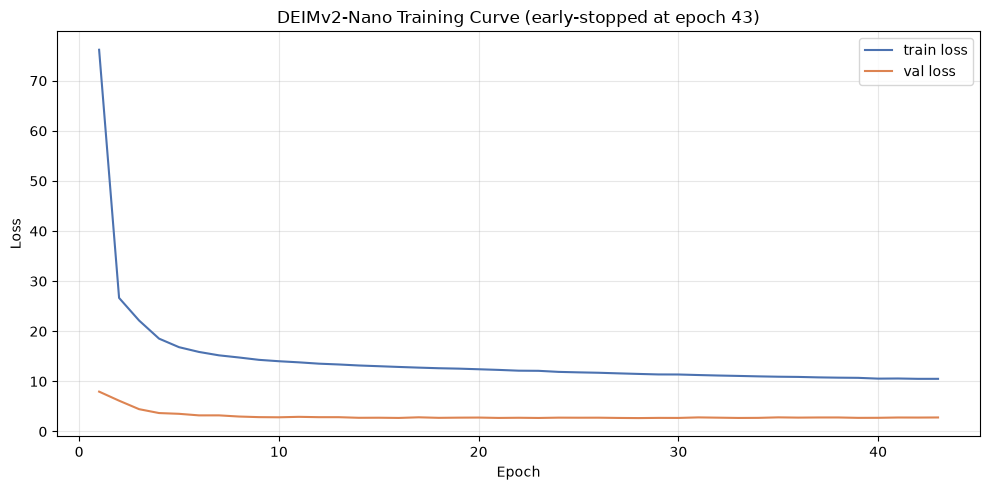

Best checkpoint (lowest val loss): C:\files\IKIU\Deep Learning\Final Project\fff-defect-detection-comparison\results\dino\run\checkpoint-2688


In [2]:
run_dir = PROJECT_ROOT / "results" / "dino" / "run"
checkpoint_dirs = sorted(run_dir.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[1]))

trainer_state_path = checkpoint_dirs[-1] / "trainer_state.json"
with open(trainer_state_path) as f:
    trainer_state = json.load(f)

log_history = trainer_state["log_history"]

train_logs = [entry for entry in log_history if "loss" in entry and "eval_loss" not in entry]
eval_logs = [entry for entry in log_history if "eval_loss" in entry]

train_df = pd.DataFrame(train_logs)
eval_df = pd.DataFrame(eval_logs)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_df["epoch"], train_df["loss"], label="train loss", color="#4C72B0")
ax.plot(eval_df["epoch"], eval_df["eval_loss"], label="val loss", color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"DEIMv2-Nano Training Curve (early-stopped at epoch {int(train_df['epoch'].max())})")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "dino_training_curve.png", dpi=150)
plt.show()

print(f"Best checkpoint (lowest val loss): {trainer_state.get('best_model_checkpoint', 'N/A')}")

## Three-way comparison: YOLOv8n vs. RT-DETR-L vs. DEIMv2-Nano (DINO substitute)

**Important caveat on comparability:** YOLOv8/RT-DETR's FPS and recall
come from Ultralytics' built-in validator (batched, optimized, recall
at IoU=0.5 with confidence filtering). DEIMv2's FPS and recall come
from a manual single-image inference loop and torchmetrics' COCO-style
`mar_100` (mean recall across IoU 0.5-0.95, capped at 100 detections
per image) -- a different, non-directly-comparable definition and
measurement method. mAP50 and mAP50-95 are more directly comparable,
since both frameworks compute these the standard COCO way.

In [3]:
comparison = pd.DataFrame({
    "Metric": ["mAP50", "mAP50-95", "Recall*", "FPS*", "Parameters (M)", "Model size (MB)"],
    "YOLOv8n": [
        yolov8_report["mAP50"], yolov8_report["mAP50_95"],
        yolov8_report["recall"], yolov8_report["FPS"],
        yolov8_report["parameters"] / 1e6, yolov8_report["model_size_MB"],
    ],
    "RT-DETR-L": [
        rtdetr_report["mAP50"], rtdetr_report["mAP50_95"],
        rtdetr_report["recall"], rtdetr_report["FPS"],
        rtdetr_report["parameters"] / 1e6, rtdetr_report["model_size_MB"],
    ],
    "DEIMv2-Nano (DINO sub.)": [
        dino_report["mAP50"], dino_report["mAP50_95"],
        dino_report["recall"], dino_report["FPS"],
        dino_report["parameters"] / 1e6, dino_report["model_size_MB"],
    ],
})
comparison

,Metric,YOLOv8n,RT-DETR-L,DEIMv2-Nano (DINO sub.)
0,mAP50,0.890197,0.969048,0.963556
1,mAP50-95,0.554766,0.651050,0.655215
2,Recall*,0.831045,0.937689,0.767535
3,FPS*,64.690000,37.630000,19.310000
4,Parameters (M),3.011823,32.816351,3.556617
5,Model size (MB),5.960000,251.470000,13.750000


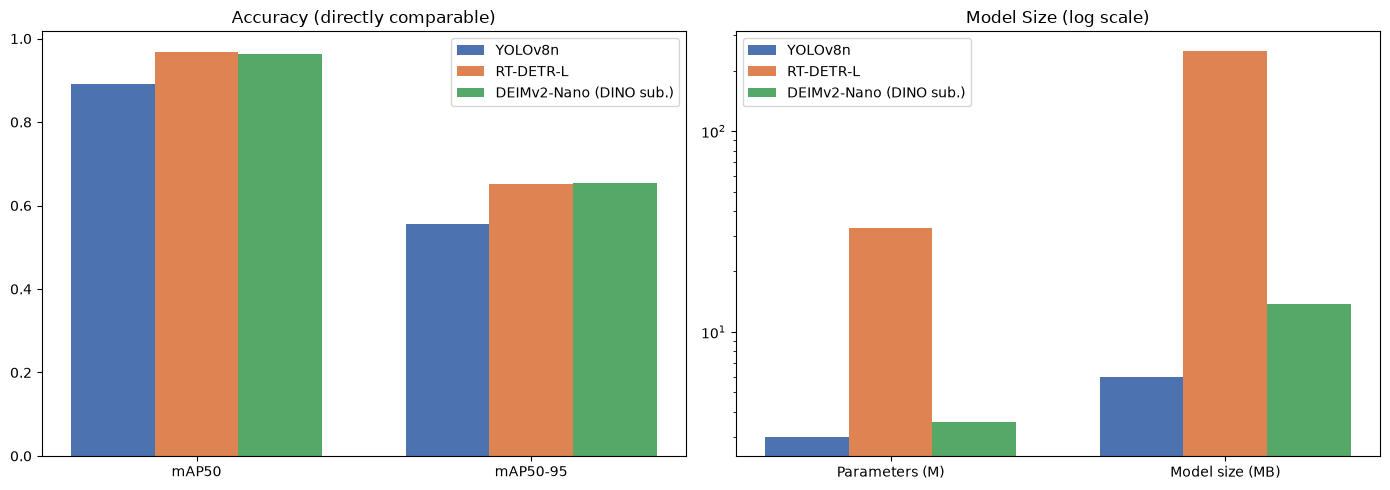

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = ["YOLOv8n", "RT-DETR-L", "DEIMv2-Nano (DINO sub.)"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

map_metrics = comparison[comparison["Metric"].isin(["mAP50", "mAP50-95"])]
x1 = range(len(map_metrics))
width = 0.25
for i, model in enumerate(models):
    axes[0].bar([p + i * width for p in x1], map_metrics[model], width, label=model, color=colors[i])
axes[0].set_xticks([p + width for p in x1])
axes[0].set_xticklabels(map_metrics["Metric"])
axes[0].set_title("Accuracy (directly comparable)")
axes[0].legend()

other_metrics = comparison[comparison["Metric"].isin(["Parameters (M)", "Model size (MB)"])]
x2 = range(len(other_metrics))
for i, model in enumerate(models):
    axes[1].bar([p + i * width for p in x2], other_metrics[model], width, label=model, color=colors[i])
axes[1].set_xticks([p + width for p in x2])
axes[1].set_xticklabels(other_metrics["Metric"])
axes[1].set_yscale("log")
axes[1].set_title("Model Size (log scale)")
axes[1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "three_way_comparison.png", dpi=150)
plt.show()

## Per-class performance (DEIMv2-Nano)

In [11]:
import sys
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from transformers import AutoImageProcessor, Deimv2ForObjectDetection
from torchmetrics.detection.mean_ap import MeanAveragePrecision

best_checkpoint = trainer_state.get("best_model_checkpoint")
model = Deimv2ForObjectDetection.from_pretrained(best_checkpoint)
image_processor = AutoImageProcessor.from_pretrained("harshaljanjani/DEIMv2_HGNetv2_N_COCO_Transformers")
model.eval()

with open(PROJECT_ROOT / "data" / "processed" / "train" / "_annotations.coco.json") as f:
    train_coco = json.load(f)
cats_sorted = sorted(train_coco["categories"], key=lambda c: c["id"])
coco_id_to_contiguous = {c["id"]: i for i, c in enumerate(cats_sorted)}
class_names = [c["name"] for c in cats_sorted]

test_dir = PROJECT_ROOT / "data" / "processed" / "test"
with open(test_dir / "_annotations.coco.json") as f:
    test_coco = json.load(f)

images_by_id = {img["id"]: img for img in test_coco["images"]}
anns_by_image = {}
for ann in test_coco["annotations"]:
    anns_by_image.setdefault(ann["image_id"], []).append(ann)

metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)

with torch.no_grad():
    for image_id, img_info in images_by_id.items():
        img_path = test_dir / "images" / img_info["file_name"]
        image = Image.open(img_path).convert("RGB")

        inputs = image_processor(images=image, return_tensors="pt")
        outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]])
        results = image_processor.post_process_object_detection(
            outputs, threshold=0.0, target_sizes=target_sizes
        )[0]

        pred = {"boxes": results["boxes"], "scores": results["scores"], "labels": results["labels"]}

        gt_anns = anns_by_image.get(image_id, [])
        gt_boxes, gt_labels = [], []
        for ann in gt_anns:
            x, y, w, h = ann["bbox"]
            gt_boxes.append([x, y, x + w, y + h])
            gt_labels.append(coco_id_to_contiguous[ann["category_id"]])

        target = {
            "boxes": torch.tensor(gt_boxes) if gt_boxes else torch.zeros((0, 4)),
            "labels": torch.tensor(gt_labels, dtype=torch.long) if gt_labels else torch.zeros((0,), dtype=torch.long),
        }

        metric.update([pred], [target])

result = metric.compute()
print(result.keys())

per_class = pd.DataFrame({
    "Class": class_names,
    "mAP50-95": result["map_per_class"].tolist(),
    "mAR100": result["mar_100_per_class"].tolist(),
})
per_class

Loading weights:   0%|          | 0/619 [00:00<?, ?it/s]

dict_keys(['map', 'map_50', 'map_75', 'map_small', 'map_medium', 'map_large', 'mar_1', 'mar_10', 'mar_100', 'mar_small', 'mar_medium', 'mar_large', 'map_per_class', 'mar_100_per_class', 'classes'])


,Class,mAP50-95,mAR100
0,Cracking,0.686528,0.769492
1,Layer_shifting,0.747164,0.841667
2,Off_platform,0.685300,0.790000
3,Stringing,0.755526,0.832584
4,Warping,0.402989,0.609091


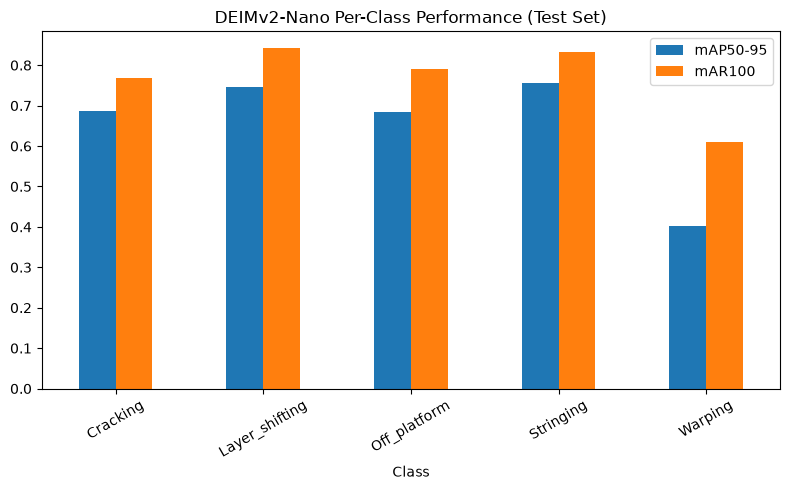

In [12]:
per_class.set_index("Class")[["mAP50-95", "mAR100"]].plot(
    kind="bar", figsize=(8, 5), rot=30
)
plt.title("DEIMv2-Nano Per-Class Performance (Test Set)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "report" / "figures" / "dino_per_class.png", dpi=150)
plt.show()

## Summary

- DEIMv2-Nano (substituting for official DINO, blocked by CUDA
  compilation incompatibility on two independent machines) achieved
  the **best mAP50-95 of all three detectors** (0.655), with a
  parameter count (3.56M) comparable to YOLOv8n.
- Trained in 43 epochs / 1.4 hours -- far faster than RT-DETR-L's
  training, likely due to the smaller Nano backbone and lower,
  RT-DETR-lesson-informed learning rate (0.0001) avoiding instability
  from the start.
- Recall and FPS figures are **not directly comparable** to the other
  two models due to different measurement methodology (see caveat
  above) -- only mAP50/mAP50-95 should be treated as apples-to-apples
  across all three.
- This result, combined with the documented, independently-verified
  reason for the substitution, will be presented to the course
  instructor for confirmation before being treated as final for
  grading purposes.